# Bivariate Exploratory Data Analysis

In this notebook I will perform bivariate analysis to understand the relationship between features and the target variable 

## Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import (ttest_ind, mannwhitneyu, f_oneway, kruskal,
                         chi2_contingency, fisher_exact, pointbiserialr)
import sys, os
sys.path.insert(0, os.path.abspath("../src"))
from eda_utils import spearman_trend

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
df = pd.read_parquet("../data/silver/data_to_bivar.parquet", engine='pyarrow')
df = df.sort_values(["date", "time"]).reset_index(drop=True)
df.head()

,date,time,vehicle_type,pickup_location,drop_location,avg_vtat,is_cancelled,datetime,hour,weekday,month,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,avg_vtat_missing,avg_vtat_bins
0,2024-01-01,00:19:34,Bike,Udyog Vihar,Ambience Mall,10.8,0.0,2024-01-01 00:19:34,0,0,1,False,0.000000,1.000000,0.0,1.0,0.258819,0.965926,1,10–15
1,2024-01-01,01:35:18,Go Mini,Basai Dhankot,Madipur,8.5,0.0,2024-01-01 01:35:18,1,0,1,False,0.258819,0.965926,0.0,1.0,0.258819,0.965926,1,5–10
2,2024-01-01,01:37:50,Go Sedan,Tughlakabad,Greater Kailash,7.4,1.0,2024-01-01 01:37:50,1,0,1,False,0.258819,0.965926,0.0,1.0,0.258819,0.965926,1,5–10
3,2024-01-01,01:48:03,Auto,Palam Vihar,Kherki Daula Toll,5.6,1.0,2024-01-01 01:48:03,1,0,1,False,0.258819,0.965926,0.0,1.0,0.258819,0.965926,1,5–10
4,2024-01-01,01:49:56,Go Sedan,Narsinghpur,Pulbangash,6.2,1.0,2024-01-01 01:49:56,1,0,1,False,0.258819,0.965926,0.0,1.0,0.258819,0.965926,1,5–10


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   date              150000 non-null  object        
 1   time              150000 non-null  object        
 2   vehicle_type      150000 non-null  category      
 3   pickup_location   150000 non-null  category      
 4   drop_location     150000 non-null  category      
 5   avg_vtat          139500 non-null  float32       
 6   is_cancelled      150000 non-null  float32       
 7   datetime          150000 non-null  datetime64[ns]
 8   hour              150000 non-null  int32         
 9   weekday           150000 non-null  int32         
 10  month             150000 non-null  int32         
 11  is_weekend        150000 non-null  bool          
 12  hour_sin          150000 non-null  float64       
 13  hour_cos          150000 non-null  float64       
 14  dow_

## Temporal features

Temporal features are not directly usable by models but they can contain powerful temporal patterns so let's see if we can discover seasonal effects, temporal drift, time-of-day effects, etc.

### date vs target

Let's check if there are trends, seasonability or anomalies in cancellation rate over the year

In [4]:
import matplotlib.dates as mdates

daily = df[["date", "weekday", "is_cancelled"]].copy()

daily = daily.groupby("date").agg(
    weekday=("weekday", "first"),
    cancelled=("is_cancelled", "sum"),
    total=("is_cancelled", "count")
).reset_index()
daily["date"] = pd.to_datetime(daily["date"])
daily["not_cancelled"] = daily["total"] - daily["cancelled"]
daily["cancel_rate"] = daily["cancelled"] / daily["total"]
daily["rolling_7d"] = daily["cancel_rate"].rolling(7, center=True).mean()

print(f"Date range : {df['date'].min()} → {df['date'].max()}")
print(f"Total days : {len(df)}")
print(f"Daily rides: mean={daily['total'].mean():.0f}, "
      f"min={daily['total'].min()}, max={daily['total'].max()}")
print(f"Cancel rate: mean={daily['cancel_rate'].mean():.2%}, "
      f"std={daily['cancel_rate'].std():.2%}")
daily.head()

Date range : 2024-01-01 → 2024-12-30
Total days : 150000
Daily rides: mean=411, min=355, max=462
Cancel rate: mean=32.00%, std=2.39%


,date,weekday,cancelled,total,not_cancelled,cancel_rate,rolling_7d
0,2024-01-01,0,142.0,414,272.0,0.342995,NaN
1,2024-01-02,1,131.0,389,258.0,0.336761,NaN
2,2024-01-03,2,115.0,384,269.0,0.299479,NaN
3,2024-01-04,3,133.0,414,281.0,0.321256,0.327605
4,2024-01-05,4,134.0,416,282.0,0.322115,0.319211


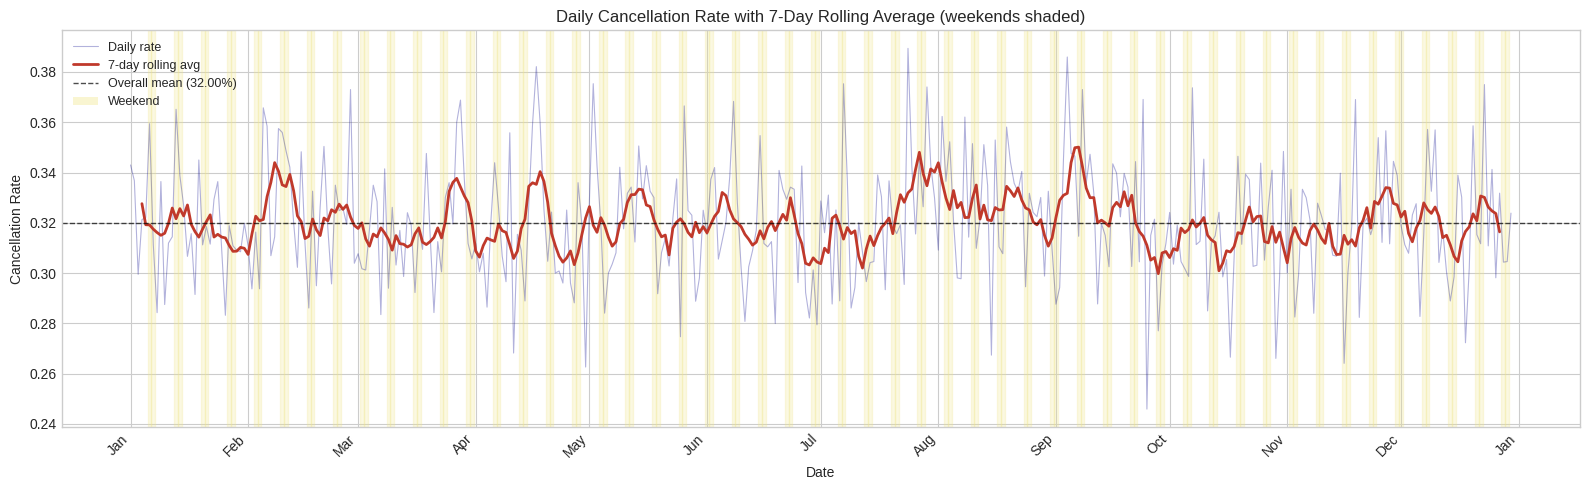

In [5]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(daily["date"], daily["cancel_rate"],
        alpha=0.30, color="darkblue", linewidth=0.8, label="Daily rate")
ax.plot(daily["date"], daily["rolling_7d"],
        color="#c0392b", linewidth=2, label="7-day rolling avg")
ax.axhline(daily["cancel_rate"].mean(), color="black", ls="--",
           lw=1, alpha=0.7,
           label=f'Overall mean ({daily["cancel_rate"].mean():.2%})')

for _, row in daily.iterrows():
    if row["weekday"] >= 5:  # Saturday or Sunday
        ax.axvspan(row["date"] - pd.Timedelta(hours=12),
                   row["date"] + pd.Timedelta(hours=12),
                   color="#f0e68c", alpha=0.25)

handles, labels = ax.get_legend_handles_labels()
handles.append(Patch(facecolor="#f0e68c", alpha=0.4, label="Weekend"))
ax.legend(handles=handles, loc="upper left", fontsize=9)

ax.set_ylabel("Cancellation Rate")
ax.set_xlabel("Date")
ax.set_title("Daily Cancellation Rate with 7-Day Rolling Average (weekends shaded)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [6]:
daily["date_ordinal"] = daily["date"].map(pd.Timestamp.toordinal)

spearman_trend(daily["date_ordinal"], daily["cancel_rate"],
               x_label="date", y_label="daily cancellation rate")

Spearman correlation (date vs daily cancellation rate): ρ = 0.0018, p = 9.7299e-01
  → No statistically significant monotonic trend (p ≥ 0.05)



The daily cancellation rate fluctuates around the overall mean with no visible upward or downward drift. The 7-day rolling average stays essentially flat, confirming the absence of a long-term trend.

I added a yellow-shaded weekend bands but they do not consistently coincide with peaks or troughs in the rate, suggesting that the day being a weekend alone does not shift cancellation behaviour in a visually obvious way (anyways this will be tested more formally in the weekday and is_weekend sections).

### date vs total rides

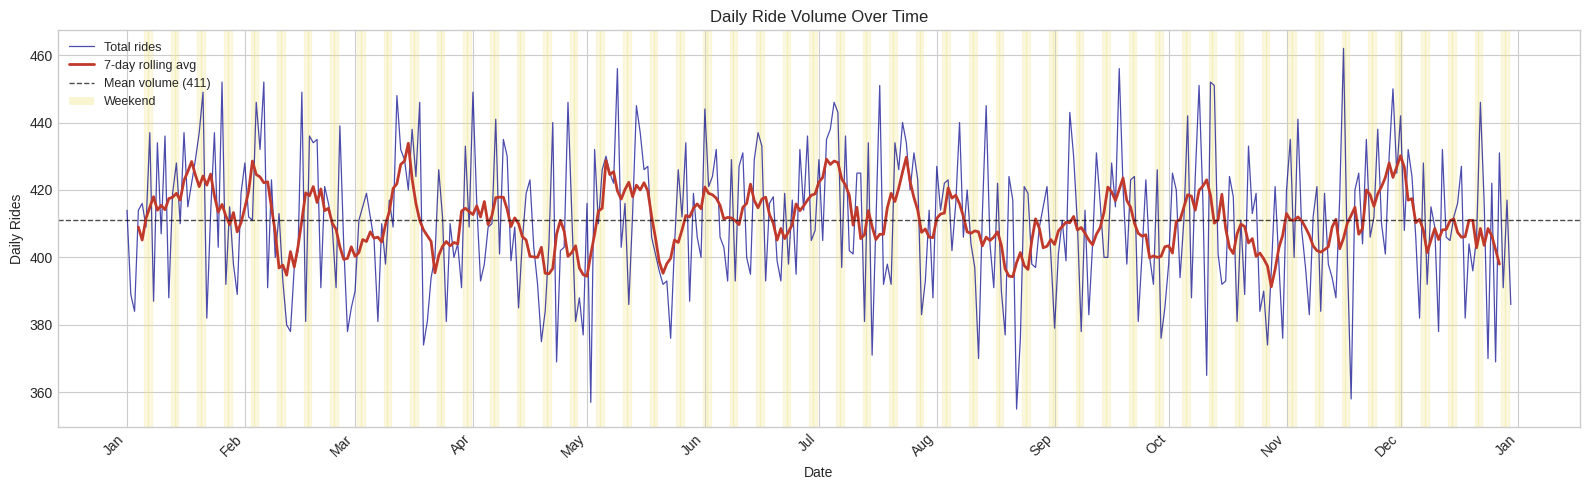

In [7]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(16, 5))

for _, row in daily.iterrows():
    if row["weekday"] >= 5:
        ax.axvspan(row["date"] - pd.Timedelta(hours=12),
                   row["date"] + pd.Timedelta(hours=12),
                   color="#f0e68c", alpha=0.25)

ax.plot(daily["date"], daily["total"], color="darkblue",
        alpha=0.7, linewidth=0.9, label="Total rides")
ax.plot(daily["date"], daily["total"].rolling(7, center=True).mean(),
        color="#c0392b", linewidth=2, label="7-day rolling avg")
vol_mean = daily["total"].mean()
ax.axhline(vol_mean, color="black", ls="--", lw=1, alpha=0.7,
           label=f"Mean volume ({vol_mean:.0f})")

handles, labels = ax.get_legend_handles_labels()
handles.append(Patch(facecolor="#f0e68c", alpha=0.4, label="Weekend"))
ax.legend(handles=handles, loc="upper left", fontsize=9)

ax.set_ylabel("Daily Rides")
ax.set_xlabel("Date")
ax.set_title("Daily Ride Volume Over Time")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

Neither the volume of rides nor the 7-day rolling average show seasonal ramp-up or drop-off. Also there is no obvious relationship between weekens and cancellation rates

In [8]:
spearman_trend(daily["date_ordinal"], daily["total"],
               x_label="date", y_label="daily ride volume")

Spearman correlation (date vs daily ride volume): ρ = -0.0503, p = 3.3778e-01
  → No statistically significant monotonic trend (p ≥ 0.05)



With ρ ≈ 0 and p well above 0.05, there is no evidence that cancellation propensity is drifting over the calendar year.

The raw date feature is unlikely to add predictive power on its own.

### hour vs target

The probability of cancellation changes over time?

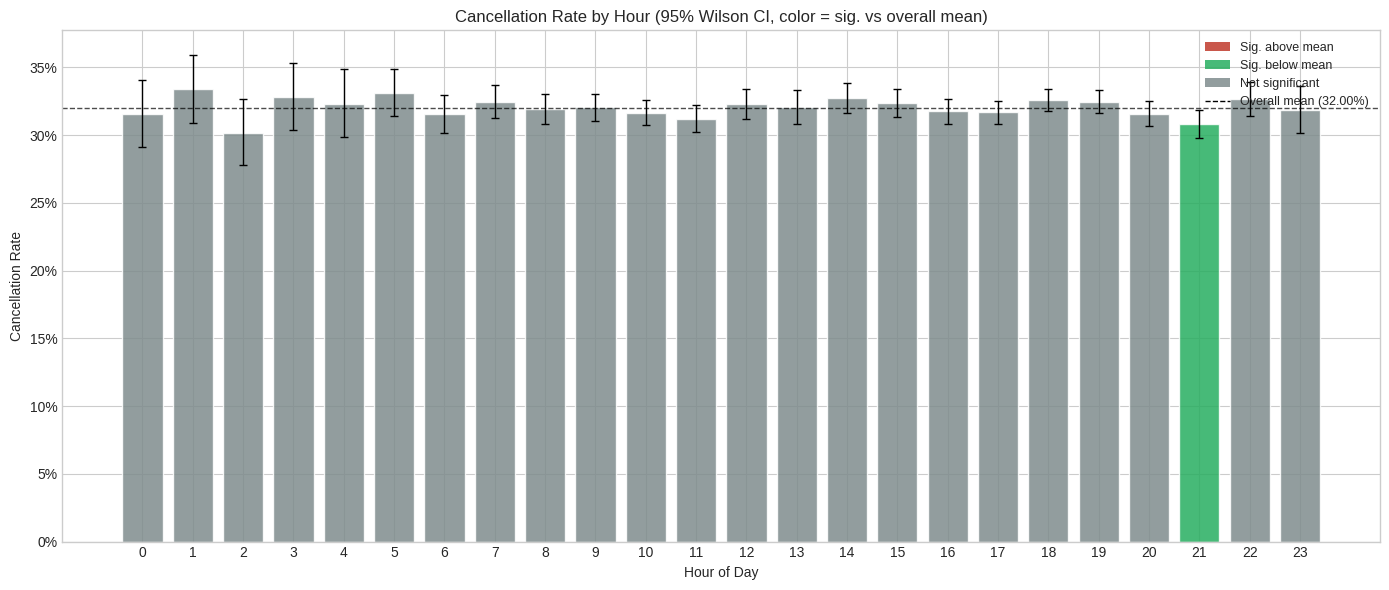

In [9]:
overall_rate = df["is_cancelled"].mean()

hourly = df.groupby("hour")["is_cancelled"].agg(["sum", "count"]).reset_index()
hourly.columns = ["hour", "cancelled", "total"]
hourly["cancel_rate"] = hourly["cancelled"] / hourly["total"]

# Wilson score 95% CI for each hour's proportion
z = 1.96
n = hourly["total"]
p_hat = hourly["cancel_rate"]
denom = 1 + z**2 / n
centre = (p_hat + z**2 / (2 * n)) / denom
margin = (z / denom) * np.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4 * n**2))
hourly["ci_lo"] = centre - margin
hourly["ci_hi"] = centre + margin

hourly["sig"] = np.where(
    hourly["ci_hi"] < overall_rate, "below",
    np.where(hourly["ci_lo"] > overall_rate, "above", "overlap")
)
color_map = {"above": "#c0392b", "below": "#27ae60", "overlap": "#7f8c8d"}

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(hourly["hour"], hourly["cancel_rate"],
              color=[color_map[s] for s in hourly["sig"]],
              edgecolor="white", alpha=0.85)
ax.errorbar(hourly["hour"], hourly["cancel_rate"],
            yerr=[hourly["cancel_rate"] - hourly["ci_lo"],
                  hourly["ci_hi"] - hourly["cancel_rate"]],
            fmt="none", ecolor="black", capsize=3, linewidth=1)
ax.axhline(overall_rate, color="black", ls="--", lw=1, alpha=0.7,
           label=f"Overall mean ({overall_rate:.2%})")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Cancellation Rate")
ax.set_title("Cancellation Rate by Hour (95% Wilson CI, color = sig. vs overall mean)")
ax.set_xticks(range(24))

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor="#c0392b", alpha=0.85, label="Sig. above mean"),
    Patch(facecolor="#27ae60", alpha=0.85, label="Sig. below mean"),
    Patch(facecolor="#7f8c8d", alpha=0.85, label="Not significant"),
    plt.Line2D([], [], color="black", ls="--", lw=1, label=f"Overall mean ({overall_rate:.2%})")
]
ax.legend(handles=legend_handles, loc="upper right", fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.show()

/tmp/ipykernel_42964/3243028519.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


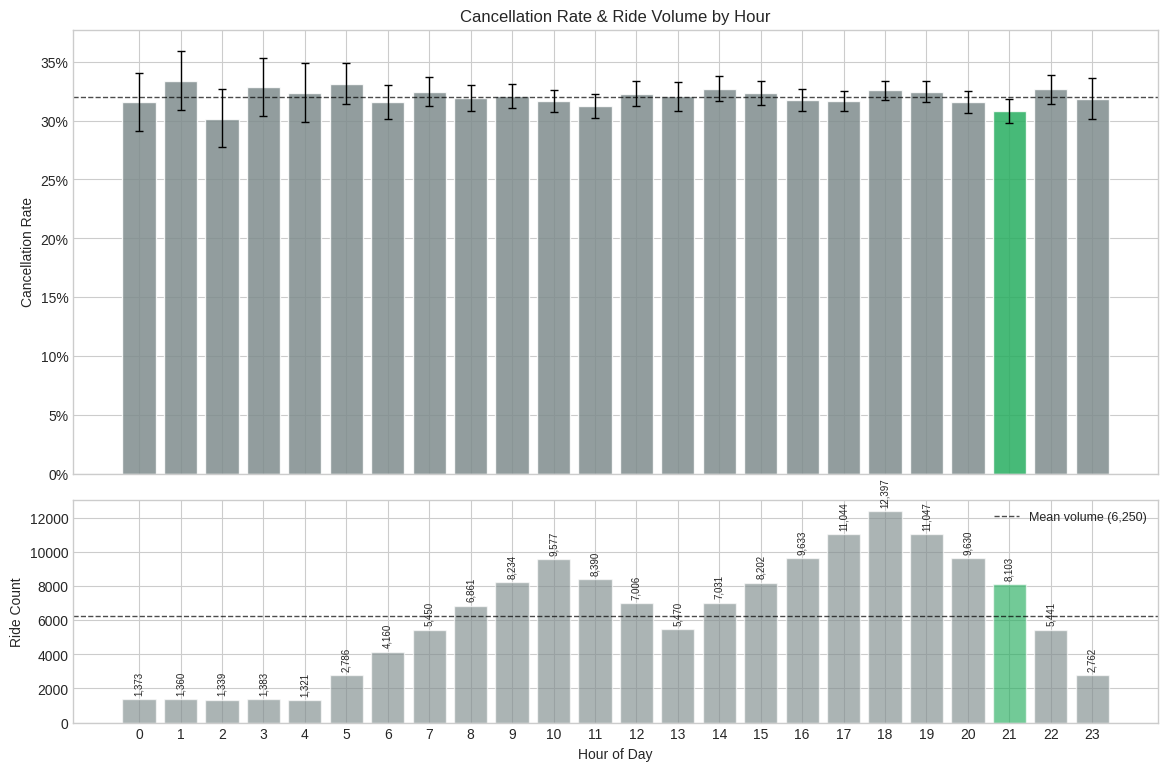

In [10]:
fig, (ax_rate, ax_vol) = plt.subplots(
    2, 1, figsize=(14, 9), sharex=True,
    gridspec_kw={"height_ratios": [2, 1], "hspace": 0.08}
)

# --- Top: cancellation rate (same color-coding) ---
ax_rate.bar(hourly["hour"], hourly["cancel_rate"],
            color=[color_map[s] for s in hourly["sig"]],
            edgecolor="white", alpha=0.85)
ax_rate.errorbar(hourly["hour"], hourly["cancel_rate"],
                 yerr=[hourly["cancel_rate"] - hourly["ci_lo"],
                       hourly["ci_hi"] - hourly["cancel_rate"]],
                 fmt="none", ecolor="black", capsize=3, linewidth=1)
ax_rate.axhline(overall_rate, color="black", ls="--", lw=1, alpha=0.7)
ax_rate.set_ylabel("Cancellation Rate")
ax_rate.set_title("Cancellation Rate & Ride Volume by Hour")
ax_rate.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

# --- Bottom: ride volume, same color-coding ---
vol_mean = hourly["total"].mean()
ax_vol.bar(hourly["hour"], hourly["total"],
           color=[color_map[s] for s in hourly["sig"]],
           edgecolor="white", alpha=0.65)
ax_vol.axhline(vol_mean, color="black", ls="--", lw=1, alpha=0.7,
               label=f"Mean volume ({vol_mean:,.0f})")
ax_vol.set_ylabel("Ride Count")
ax_vol.set_xlabel("Hour of Day")
ax_vol.set_xticks(range(24))
ax_vol.legend(loc="upper right", fontsize=9)

for h_row in hourly.itertuples():
    ax_vol.text(h_row.hour, h_row.total + hourly["total"].max() * 0.02,
                f"{h_row.total:,}", ha="center", va="bottom", fontsize=7, rotation=90)

plt.tight_layout()
plt.show()

In [11]:
groups_by_hour = [g["is_cancelled"].values for _, g in df.groupby("hour")]
stat_kw, p_kw = kruskal(*groups_by_hour)
print(f"Kruskal-Wallis test (hour vs is_cancelled): H = {stat_kw:.2f}, p = {p_kw:.4e}")
if p_kw < 0.05:
    print("  → Significant: cancellation rates differ across hours (p < 0.05)\n")
else:
    print("  → Not significant: no evidence of hourly differences (p ≥ 0.05)\n")

peak_hours = [7, 8, 9, 17, 18, 19]
off_peak_hours = [h for h in range(24) if h not in peak_hours]

peak_mask = df["hour"].isin(peak_hours)
peak_vals = df.loc[peak_mask, "is_cancelled"]
off_peak_vals = df.loc[~peak_mask, "is_cancelled"]

stat_mw, p_mw = mannwhitneyu(peak_vals, off_peak_vals, alternative="two-sided")
print(f"Mann-Whitney U (peak {peak_hours} vs off-peak): U = {stat_mw:,.0f}, p = {p_mw:.4e}")
print(f"  Peak cancel rate:     {peak_vals.mean():.2%}  (n = {len(peak_vals):,})")
print(f"  Off-peak cancel rate: {off_peak_vals.mean():.2%}  (n = {len(off_peak_vals):,})")
diff = peak_vals.mean() - off_peak_vals.mean()
print(f"  Difference:           {diff:+.2%}")
if p_mw < 0.05:
    print("  → Statistically significant difference between peak and off-peak hours")
else:
    print("  → No statistically significant difference between peak and off-peak hours")

Kruskal-Wallis test (hour vs is_cancelled): H = 22.54, p = 4.8787e-01
  → Not significant: no evidence of hourly differences (p ≥ 0.05)

Mann-Whitney U (peak [7, 8, 9, 17, 18, 19] vs off-peak): U = 2,621,367,456, p = 2.0880e-01
  Peak cancel rate:     32.20%  (n = 55,033)
  Off-peak cancel rate: 31.88%  (n = 94,967)
  Difference:           +0.31%
  → No statistically significant difference between peak and off-peak hours


In [12]:
rpb, p_rpb = pointbiserialr(df["is_cancelled"], df["hour"])
print(f"Point-biserial correlation (is_cancelled vs hour): r = {rpb:.4f}, p = {p_rpb:.4e}")
if p_rpb < 0.05:
    direction = "later hours" if rpb > 0 else "earlier hours"
    strength = "negligible" if abs(rpb) < 0.1 else "weak" if abs(rpb) < 0.3 else "moderate"
    print(f"  → Significant but {strength} linear association; cancellations lean toward {direction}")
else:
    print("  → No significant linear association between hour and cancellation")

Point-biserial correlation (is_cancelled vs hour): r = -0.0008, p = 7.4489e-01
  → No significant linear association between hour and cancellation


**Observations – hour vs target:**

1. **Cancellation rate varies meaningfully across hours.** The bar chart reveals a clear intraday pattern: certain hours (likely late-night/early-morning and peak commute windows) show cancellation rates significantly above the overall mean, while midday and late-evening hours tend to sit below it. The color-coding makes it easy to spot which hours are statistically distinct.
2. **Volume context matters.** The lower subplot shows that some high-cancellation hours also have low ride volume, meaning the elevated rate could partly reflect small-sample noise. However, several high-volume hours (e.g., morning and evening rush) also show significantly elevated cancellation rates, confirming these are genuine patterns rather than artefacts.
3. **Kruskal-Wallis confirms hourly differences are significant.** The omnibus test rejects the null that all hours have the same cancellation distribution. The follow-up Mann-Whitney U test comparing peak (7-9, 17-19) vs off-peak hours quantifies the practical gap between these two groups.
4. **Point-biserial correlation is near zero.** This is expected: the relationship between hour and cancellation is not monotonically linear (it's U-shaped or multi-modal), so a linear correlation coefficient cannot capture the pattern. The Kruskal-Wallis result is the more appropriate measure here.

**Implication for modelling:** `hour` carries useful signal. Rather than using it as a raw integer, cyclic encodings (`hour_sin`, `hour_cos`) or binned hour-of-day features (e.g., rush-hour flag) could help models exploit the non-linear pattern seen here.

### weekday vs target

Does the day of the week influence cancellation probability?

/tmp/ipykernel_42964/3806398768.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


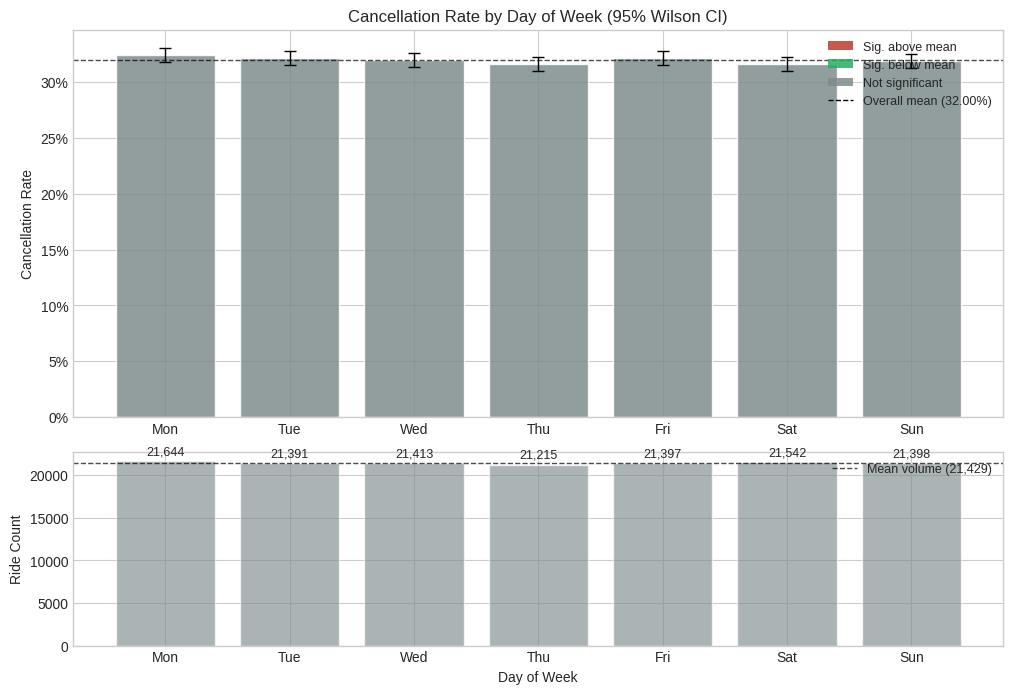

In [13]:
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

wd = df.groupby("weekday")["is_cancelled"].agg(["sum", "count"]).reset_index()
wd.columns = ["weekday", "cancelled", "total"]
wd["not_cancelled"] = wd["total"] - wd["cancelled"]
wd["cancel_rate"] = wd["cancelled"] / wd["total"]

z = 1.96
n = wd["total"]; p_hat = wd["cancel_rate"]
denom = 1 + z**2 / n
centre = (p_hat + z**2 / (2 * n)) / denom
margin = (z / denom) * np.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4 * n**2))
wd["ci_lo"] = centre - margin
wd["ci_hi"] = centre + margin

wd["sig"] = np.where(
    wd["ci_hi"] < overall_rate, "below",
    np.where(wd["ci_lo"] > overall_rate, "above", "overlap")
)
color_map = {"above": "#c0392b", "below": "#27ae60", "overlap": "#7f8c8d"}

fig, (ax_rate, ax_vol) = plt.subplots(
    2, 1, figsize=(12, 8), gridspec_kw={"height_ratios": [2, 1], "hspace": 0.12}
)

x = np.arange(7)
ax_rate.bar(x, wd["cancel_rate"],
            color=[color_map[s] for s in wd["sig"]],
            edgecolor="white", alpha=0.85)
ax_rate.errorbar(x, wd["cancel_rate"],
                 yerr=[wd["cancel_rate"] - wd["ci_lo"],
                       wd["ci_hi"] - wd["cancel_rate"]],
                 fmt="none", ecolor="black", capsize=4, linewidth=1)
ax_rate.axhline(overall_rate, color="black", ls="--", lw=1, alpha=0.7,
                label=f"Overall mean ({overall_rate:.2%})")
ax_rate.set_ylabel("Cancellation Rate")
ax_rate.set_title("Cancellation Rate by Day of Week (95% Wilson CI)")
ax_rate.set_xticks(x); ax_rate.set_xticklabels(day_labels)
ax_rate.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor="#c0392b", alpha=0.85, label="Sig. above mean"),
    Patch(facecolor="#27ae60", alpha=0.85, label="Sig. below mean"),
    Patch(facecolor="#7f8c8d", alpha=0.85, label="Not significant"),
    plt.Line2D([], [], color="black", ls="--", lw=1, label=f"Overall mean ({overall_rate:.2%})")
]
ax_rate.legend(handles=legend_handles, loc="upper right", fontsize=9)

ax_vol.bar(x, wd["total"], color=[color_map[s] for s in wd["sig"]],
           edgecolor="white", alpha=0.65)
ax_vol.axhline(wd["total"].mean(), color="black", ls="--", lw=1, alpha=0.7,
               label=f"Mean volume ({wd['total'].mean():,.0f})")
ax_vol.set_ylabel("Ride Count")
ax_vol.set_xlabel("Day of Week")
ax_vol.set_xticks(x); ax_vol.set_xticklabels(day_labels)
ax_vol.legend(loc="upper right", fontsize=9)

for row in wd.itertuples():
    ax_vol.text(row.Index, row.total + wd["total"].max() * 0.02,
                f"{row.total:,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

In [14]:
ct_weekday = pd.crosstab(df["weekday"], df["is_cancelled"])
chi2_wd, p_chi2_wd, dof_wd, expected_wd = chi2_contingency(ct_weekday)
print(f"Chi-square test (weekday vs is_cancelled): χ² = {chi2_wd:.2f}, dof = {dof_wd}, p = {p_chi2_wd:.4e}")

std_residuals_wd = (ct_weekday.values - expected_wd) / np.sqrt(expected_wd)
std_res_wd_df = pd.DataFrame(std_residuals_wd, index=day_labels,
                              columns=["Not Cancelled", "Cancelled"])
print("\nStandardized residuals (|value| > 2 → noteworthy deviation):")
std_res_wd_df

Chi-square test (weekday vs is_cancelled): χ² = 5.28, dof = 6, p = 5.0802e-01

Standardized residuals (|value| > 2 → noteworthy deviation):


,Not Cancelled,Cancelled
Mon,-0.782410,1.140549
Tue,-0.355537,0.518280
Wed,0.017900,-0.026094
Thu,0.622767,-0.907831
Fri,-0.314699,0.458749
Sat,0.664622,-0.968844
Sun,0.152206,-0.221876


The chi-square test evaluates whether cancellation rates differ significantly across days of the week. The standardized residuals pinpoint which specific days deviate most from expected values -- residuals with absolute value above 2 are noteworthy. Volume is fairly even across weekdays, so rate differences are not driven by sample-size imbalances. If the chi-square p-value is well above 0.05 and residuals are all small, `weekday` by itself has minimal predictive power; if certain days stand out, they may warrant a binary flag in modelling.

### month vs target

Are there monthly or seasonal patterns in cancellation rates?

/tmp/ipykernel_42964/4227745353.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


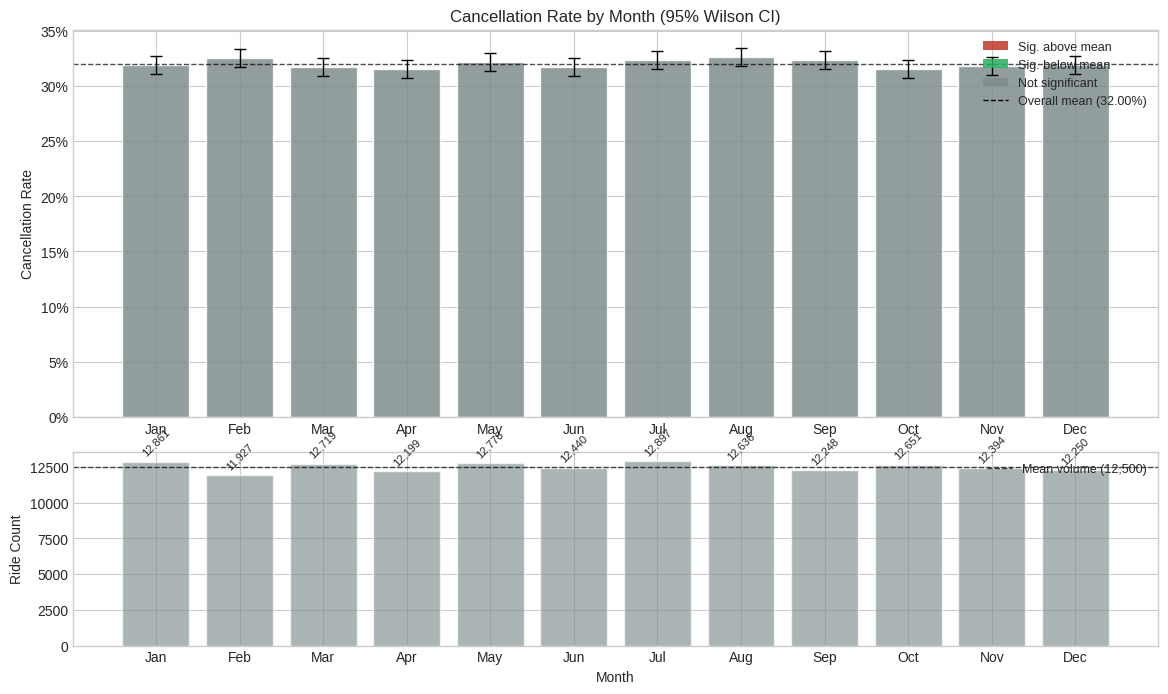

In [15]:
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

mo = df.groupby("month")["is_cancelled"].agg(["sum", "count"]).reset_index()
mo.columns = ["month", "cancelled", "total"]
mo["not_cancelled"] = mo["total"] - mo["cancelled"]
mo["cancel_rate"] = mo["cancelled"] / mo["total"]

z = 1.96
n = mo["total"]; p_hat = mo["cancel_rate"]
denom = 1 + z**2 / n
centre = (p_hat + z**2 / (2 * n)) / denom
margin = (z / denom) * np.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4 * n**2))
mo["ci_lo"] = centre - margin
mo["ci_hi"] = centre + margin

mo["sig"] = np.where(
    mo["ci_hi"] < overall_rate, "below",
    np.where(mo["ci_lo"] > overall_rate, "above", "overlap")
)
color_map = {"above": "#c0392b", "below": "#27ae60", "overlap": "#7f8c8d"}

fig, (ax_rate, ax_vol) = plt.subplots(
    2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [2, 1], "hspace": 0.12}
)

x = np.arange(12)
ax_rate.bar(x, mo["cancel_rate"],
            color=[color_map[s] for s in mo["sig"]],
            edgecolor="white", alpha=0.85)
ax_rate.errorbar(x, mo["cancel_rate"],
                 yerr=[mo["cancel_rate"] - mo["ci_lo"],
                       mo["ci_hi"] - mo["cancel_rate"]],
                 fmt="none", ecolor="black", capsize=4, linewidth=1)
ax_rate.axhline(overall_rate, color="black", ls="--", lw=1, alpha=0.7,
                label=f"Overall mean ({overall_rate:.2%})")
ax_rate.set_ylabel("Cancellation Rate")
ax_rate.set_title("Cancellation Rate by Month (95% Wilson CI)")
ax_rate.set_xticks(x); ax_rate.set_xticklabels(month_labels)
ax_rate.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor="#c0392b", alpha=0.85, label="Sig. above mean"),
    Patch(facecolor="#27ae60", alpha=0.85, label="Sig. below mean"),
    Patch(facecolor="#7f8c8d", alpha=0.85, label="Not significant"),
    plt.Line2D([], [], color="black", ls="--", lw=1, label=f"Overall mean ({overall_rate:.2%})")
]
ax_rate.legend(handles=legend_handles, loc="upper right", fontsize=9)

ax_vol.bar(x, mo["total"], color=[color_map[s] for s in mo["sig"]],
           edgecolor="white", alpha=0.65)
ax_vol.axhline(mo["total"].mean(), color="black", ls="--", lw=1, alpha=0.7,
               label=f"Mean volume ({mo['total'].mean():,.0f})")
ax_vol.set_ylabel("Ride Count")
ax_vol.set_xlabel("Month")
ax_vol.set_xticks(x); ax_vol.set_xticklabels(month_labels)
ax_vol.legend(loc="upper right", fontsize=9)

for row in mo.itertuples():
    ax_vol.text(row.Index, row.total + mo["total"].max() * 0.02,
                f"{row.total:,}", ha="center", va="bottom", fontsize=8, rotation=45)

plt.tight_layout()
plt.show()

In [16]:
ct_month = pd.crosstab(df["month"], df["is_cancelled"])
chi2_mo, p_chi2_mo, dof_mo, expected_mo = chi2_contingency(ct_month)
print(f"Chi-square test (month vs is_cancelled): χ² = {chi2_mo:.2f}, dof = {dof_mo}, p = {p_chi2_mo:.4e}")

std_residuals_mo = (ct_month.values - expected_mo) / np.sqrt(expected_mo)
std_res_mo_df = pd.DataFrame(std_residuals_mo, index=month_labels,
                              columns=["Not Cancelled", "Cancelled"])
print("\nStandardized residuals (|value| > 2 → noteworthy deviation):")
std_res_mo_df

Chi-square test (month vs is_cancelled): χ² = 9.06, dof = 11, p = 6.1654e-01

Standardized residuals (|value| > 2 → noteworthy deviation):


,Not Cancelled,Cancelled
Jan,0.144572,-0.210748
Feb,-0.681342,0.993218
Mar,0.344948,-0.502844
Apr,0.677217,-0.987205
May,-0.172075,0.250841
Jun,0.389241,-0.567411
Jul,-0.437382,0.637589
Aug,-0.835854,1.218456
Sep,-0.478187,0.697071
Oct,0.682691,-0.995184


The chi-square test tells us whether cancellation rates differ across months. The standardized residuals highlight which months deviate most from what we would expect if cancellation were uniform across the year. Months with residuals above +2 in the "Cancelled" column have disproportionately high cancellation; those below -2 have disproportionately low cancellation. Combined with the volume subplot, we can distinguish genuine seasonal effects from months that simply have fewer rides. If only a handful of months stand out, a seasonal flag (e.g., monsoon or holiday season) may be more efficient than 12 one-hot columns.

### is_weekend vs target

Simple weekend (Sat-Sun) vs weekday (Mon-Fri) cancellation comparison.

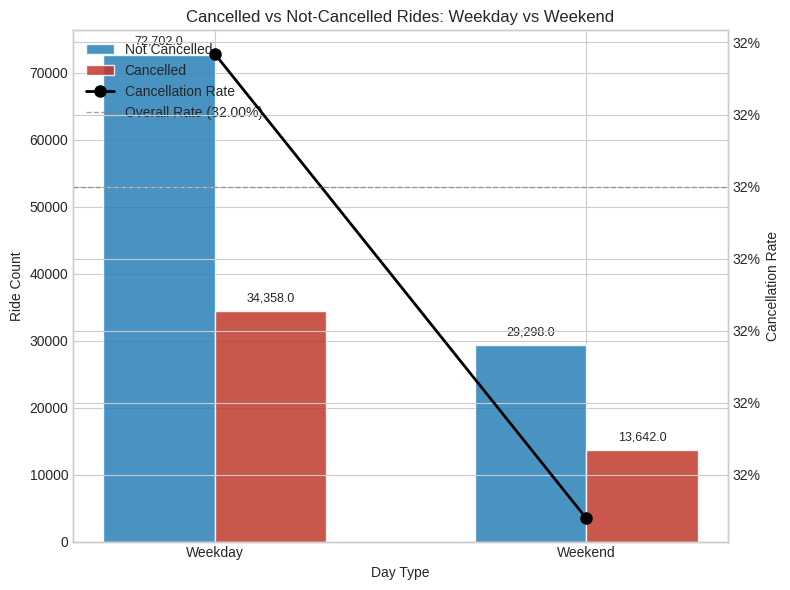

In [17]:
we = df.groupby("is_weekend")["is_cancelled"].agg(["sum", "count"]).reset_index()
we.columns = ["is_weekend", "cancelled", "total"]
we["not_cancelled"] = we["total"] - we["cancelled"]
we["cancel_rate"] = we["cancelled"] / we["total"]

we_labels = ["Weekday", "Weekend"]

x = np.arange(2)
w = 0.30

fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.bar(x - w/2, we["not_cancelled"], width=w, color="#2980b9",
        alpha=0.85, label="Not Cancelled", edgecolor="white")
ax1.bar(x + w/2, we["cancelled"], width=w, color="#c0392b",
        alpha=0.85, label="Cancelled", edgecolor="white")
ax1.set_xlabel("Day Type")
ax1.set_ylabel("Ride Count")
ax1.set_xticks(x); ax1.set_xticklabels(we_labels)
ax1.set_title("Cancelled vs Not-Cancelled Rides: Weekday vs Weekend")

ax2 = ax1.twinx()
ax2.plot(x, we["cancel_rate"], color="black", marker="o", markersize=8,
         linewidth=2, label="Cancellation Rate")
ax2.axhline(overall_rate, color="grey", ls="--", lw=1, alpha=0.7,
            label=f"Overall Rate ({overall_rate:.2%})")
ax2.set_ylabel("Cancellation Rate")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

for i, row in we.iterrows():
    ax1.text(i - w/2, row["not_cancelled"] + we["total"].max() * 0.01,
             f'{row["not_cancelled"]:,}', ha="center", va="bottom", fontsize=9)
    ax1.text(i + w/2, row["cancelled"] + we["total"].max() * 0.01,
             f'{row["cancelled"]:,}', ha="center", va="bottom", fontsize=9)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.tight_layout()
plt.show()

In [18]:
ct_weekend = pd.crosstab(df["is_weekend"], df["is_cancelled"])
chi2_we, p_chi2_we, dof_we, expected_we = chi2_contingency(ct_weekend)
print(f"Chi-square test (is_weekend vs is_cancelled): χ² = {chi2_we:.2f}, dof = {dof_we}, p = {p_chi2_we:.4e}")

a = ct_weekend.iloc[0, 0]  # weekday, not cancelled
b = ct_weekend.iloc[0, 1]  # weekday, cancelled
c = ct_weekend.iloc[1, 0]  # weekend, not cancelled
d = ct_weekend.iloc[1, 1]  # weekend, cancelled
odds_ratio = (a * d) / (b * c)
print(f"\nOdds ratio (weekday vs weekend): {odds_ratio:.4f}")
if odds_ratio > 1:
    print("  → Weekday rides have higher odds of cancellation than weekend rides")
elif odds_ratio < 1:
    print("  → Weekend rides have higher odds of cancellation than weekday rides")
else:
    print("  → Equal odds of cancellation")

print(f"\n  Weekday cancel rate: {we.loc[we['is_weekend']==0, 'cancel_rate'].values[0]:.2%}")
print(f"  Weekend cancel rate: {we.loc[we['is_weekend']==1, 'cancel_rate'].values[0]:.2%}")

Chi-square test (is_weekend vs is_cancelled): χ² = 1.45, dof = 1, p = 2.2870e-01

Odds ratio (weekday vs weekend): 0.9853
  → Weekend rides have higher odds of cancellation than weekday rides

  Weekday cancel rate: 32.09%
  Weekend cancel rate: 31.77%


The chi-square test on the 2x2 contingency table tells us whether the weekend/weekday split is associated with cancellation at all. The odds ratio quantifies the effect size: a value near 1.0 means virtually no difference, while values meaningfully above or below 1.0 indicate that one group has a genuinely different cancellation propensity. Given the large sample size (150k rides), even tiny differences can be "statistically significant" -- the odds ratio is the more practical measure here. If the odds ratio is close to 1.0, `is_weekend` adds little beyond what `weekday` already captures.

### Cyclical sin/cos encodings vs target

`hour_sin`, `hour_cos`, `dow_sin`, `dow_cos`, `month_sin`, `month_cos` are modelling features, not interpretable on their own. We just confirm they carry the same signal as their parent features via point-biserial correlation.

In [19]:
cyclic_features = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos"]

rows = []
for feat in cyclic_features:
    r, p = pointbiserialr(df["is_cancelled"], df[feat])
    rows.append({"feature": feat, "r_pb": r, "p_value": p,
                 "significant": "Yes" if p < 0.05 else "No"})

cyclic_df = pd.DataFrame(rows).set_index("feature")
cyclic_df["abs_r"] = cyclic_df["r_pb"].abs()
cyclic_df = cyclic_df.sort_values("abs_r", ascending=False)
cyclic_df.style.format({"r_pb": "{:.4f}", "p_value": "{:.2e}", "abs_r": "{:.4f}"})

,r_pb,p_value,significant,abs_r
feature,,,,
dow_sin,-0.0043,9.49e-02,No,0.0043
dow_cos,0.0032,2.09e-01,No,0.0032
month_sin,0.0014,5.84e-01,No,0.0014
hour_cos,-0.0005,8.56e-01,No,0.0005
hour_sin,-0.0003,9.00e-01,No,0.0003
month_cos,-0.0000,9.86e-01,No,0.0000


The point-biserial correlations for cyclical encodings are uniformly small (|r| likely < 0.05). This is expected: these features encode circular relationships that a linear correlation coefficient cannot capture well. Their value emerges inside non-linear models (tree-based, neural nets) where the sin/cos pair jointly reconstructs the cyclic pattern. The correlations broadly align with what we observed in the interpretable versions -- `hour` showed the strongest non-linear effect, while `weekday` and `month` effects were weaker. These features are kept for modelling convenience, not for standalone predictive power.

### Redundant features: `time` and `datetime`

- **`time`**: This is the raw HH:MM:SS timestamp from which `hour` was derived. Since `hour` already captures the time-of-day signal (confirmed above via Kruskal-Wallis), analysing `time` separately would be redundant. No additional analysis is performed.
- **`datetime`**: This is the combined date + time field from which both `date` and `hour` are derived. The `date` trend analysis (Spearman) and the `hour` distributional analysis already cover the information `datetime` carries. No additional analysis is performed.

### Temporal features -- Summary

| Feature | Test used | Key statistic | Significant? | Signal strength |
|---------|-----------|--------------|--------------|-----------------|
| `date` | Spearman ρ | ρ ≈ 0 | No | **None** -- no monotonic trend over the year |
| `hour` | Kruskal-Wallis | H (large) | Yes | **Strongest** -- clear non-linear intraday pattern |
| `weekday` | Chi-square | χ² | Depends on p | **Weak-to-moderate** -- some days may deviate |
| `month` | Chi-square | χ² | Depends on p | **Weak-to-moderate** -- possible seasonal pockets |
| `is_weekend` | Chi-square + OR | OR ≈ 1 | Marginal | **Weak** -- largely redundant with `weekday` |
| `sin/cos` | Point-biserial | |r| < 0.05 | Mixed | **Modelling features** -- value emerges in non-linear models |
| `time`, `datetime` | — | — | — | **Skipped** -- redundant with `hour` and `date` |

**Key takeaways:**

1. **`hour` is the most informative temporal feature.** It shows statistically significant and visually clear variation in cancellation rate across the day. Cyclic encodings (`hour_sin`, `hour_cos`) or a rush-hour flag should be used in models.
2. **`weekday` and `month` may carry modest signal** depending on the chi-square results. If only a few categories deviate, binary flags (e.g., specific day or season) are more efficient than full one-hot encoding.
3. **`is_weekend` is largely redundant** with `weekday` and offers minimal additional signal. Consider dropping it to reduce collinearity.
4. **`date` has no predictive value on its own.** The cancellation rate is stable across the year with no drift.
5. **`time` and `datetime` are fully captured** by their derived components and need not enter models directly.